# Notebook 13: Personalized Music Recommendation Engine

> **Project**: Music, Brain & Wellbeing Intelligence System  
> **Phase**: Phase 2 — Personalized Music Recommendation Engine

---

## Overview
This notebook demonstrates the end-to-end implementation of our **Content-Based Music Recommendation Engine**:
1. **Catalog & Profile Loading**: Loading track catalog and building quantitative user listening habit vectors.
2. **Feature Vector Alignment**: Extracting aligned user profile and candidate track feature vectors.
3. **Standardized Euclidean Distance & Similarity**: Computing geometric distance in scaled feature space ($\mu=0, \sigma=1$) and mapping to similarity scores $S = rac{1}{1 + D}$.
4. **Acoustic Profile Compatibility**: Integrating user cluster distribution shares as a secondary compatibility score.
5. **Weighted Candidate Ranking**: Combining similarity ($70\%$) and profile compatibility ($30\%$) into final recommendation scores.
6. **Diversity Filtering & Top-N Generation**: Applying cluster diversity caps and attaching deterministic machine-readable explanations.
7. **Cold Start & Non-Causal Boundaries**: Discussing cold start strategies, observational non-causal framing, and recommendation evaluation metrics.

---


### 1. Setup Environment & Import Reusable Recommendation Modules

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Ensure project root is in sys.path
sys.path.insert(0, os.path.abspath(".."))

from src.data.music_loader import load_music_catalog, load_listening_history
from src.features.music_features import validate_feature_ranges, normalize_tempo, extract_feature_matrix, scale_feature_matrix
from src.features.clustering import train_kmeans_clustering, generate_cluster_labels
from src.features.user_profile import build_user_music_profile
from src.recommendation.candidate_retrieval import retrieve_candidates
from src.recommendation.similarity import RECOMMENDATION_FEATURES, extract_user_vector, extract_track_matrix, compute_euclidean_distance, compute_similarity_score
from src.recommendation.ranking import compute_profile_compatibility, rank_candidates, apply_diversity_filter
from src.recommendation.recommender import recommend_tracks, generate_deterministic_explanation

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("Recommendation modules imported successfully.")


Recommendation modules imported successfully.


### 2. Load Track Catalog, Clustering Baseline, and User Profile

In [2]:
catalog_path = "../data/raw/spotify/tracks.csv"
history_path = "../data/processed/music/listening_history.csv"

catalog_df = load_music_catalog(catalog_path)
history_df = load_listening_history(history_path)

# Cluster catalog for acoustic profile matching (K=4)
catalog_clean = validate_feature_ranges(catalog_df)
catalog_clean = normalize_tempo(catalog_clean)
X_raw, feat_cols = extract_feature_matrix(catalog_clean)
X_scaled, scaler = scale_feature_matrix(X_raw)

kmeans_model, cluster_labels = train_kmeans_clustering(X_scaled, n_clusters=4)
catalog_clean["cluster_id"] = cluster_labels

user_profile = build_user_music_profile(history_df, catalog_clean, cluster_labels=cluster_labels)

print("User ID:", user_profile["user_id"])
print("Total Tracks Listened:", user_profile["total_tracks_listened"])
print("Audio Feature Means:", json.dumps(user_profile["audio_feature_summary"], indent=2))
print("Cluster Preference Shares:", json.dumps(user_profile["cluster_distribution"], indent=2))


User ID: USR001
Total Tracks Listened: 1000
Audio Feature Means: {
  "energy_mean": 0.5879,
  "energy_std": 0.2693,
  "valence_mean": 0.4803,
  "valence_std": 0.1769,
  "danceability_mean": 0.5302,
  "danceability_std": 0.1943,
  "acousticness_mean": 0.4542,
  "acousticness_std": 0.3488,
  "instrumentalness_mean": 0.4968,
  "instrumentalness_std": 0.3198,
  "tempo_mean": 115.4089,
  "tempo_std": 25.2798
}
Cluster Preference Shares: {
  "cluster_0": 0.355,
  "cluster_1": 0.26,
  "cluster_3": 0.214,
  "cluster_2": 0.171
}


### 3. Feature Vector Alignment & Scaling Inspection

In [3]:
user_vec = extract_user_vector(user_profile, feature_names=RECOMMENDATION_FEATURES)
track_mat = extract_track_matrix(catalog_clean, feature_names=RECOMMENDATION_FEATURES)

print("Aligned Feature Columns:", RECOMMENDATION_FEATURES)
print("User Profile Vector Shape:", user_vec.shape)
print("Track Matrix Shape:", track_mat.shape)

# Demonstrate scaling on combined matrix
combined_mat = np.vstack([user_vec, track_mat])
scaled_combined, _ = scale_feature_matrix(combined_mat)

user_vec_scaled = scaled_combined[0]
track_mat_scaled = scaled_combined[1:]

print("\nSample Raw User Vector:", np.round(user_vec, 3))
print("Sample Scaled User Vector:", np.round(user_vec_scaled, 3))


Aligned Feature Columns: ['energy', 'valence', 'danceability', 'acousticness', 'instrumentalness', 'tempo_norm']
User Profile Vector Shape: (6,)
Track Matrix Shape: (500, 6)

Sample Raw User Vector: [0.588 0.48  0.53  0.454 0.497 0.462]
Sample Scaled User Vector: [ 0.049  0.039  0.04  -0.026 -0.001  0.052]


### 4. Compute Euclidean Distance & Similarity Scores

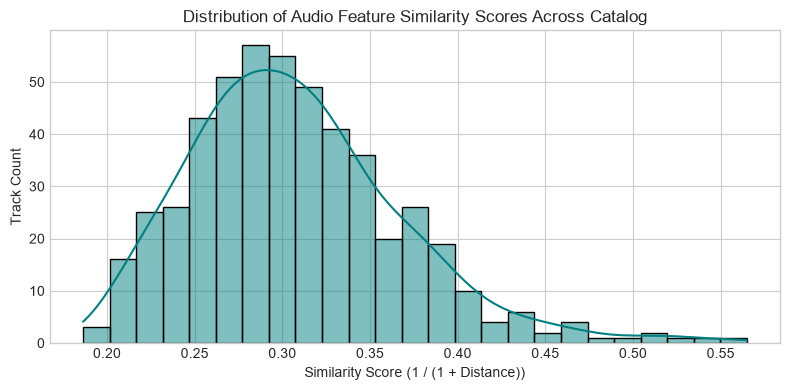

Max Similarity: 0.5649 | Min Similarity: 0.1863 | Mean: 0.3075


In [4]:
distances = compute_euclidean_distance(user_vec_scaled, track_mat_scaled)
sim_scores = compute_similarity_score(distances)

catalog_clean["euclidean_distance"] = np.round(distances, 4)
catalog_clean["similarity_score"] = np.round(sim_scores, 4)

plt.figure(figsize=(8, 4))
sns.histplot(sim_scores, bins=25, kde=True, color='teal')
plt.title("Distribution of Audio Feature Similarity Scores Across Catalog")
plt.xlabel("Similarity Score (1 / (1 + Distance))")
plt.ylabel("Track Count")
plt.tight_layout()
plt.savefig("../docs/figures/13_similarity_distribution.png", dpi=300)
plt.show()

print(f"Max Similarity: {sim_scores.max():.4f} | Min Similarity: {sim_scores.min():.4f} | Mean: {sim_scores.mean():.4f}")


### 5. Acoustic Profile Compatibility & Final Weighted Ranking

In [5]:
profile_scores = compute_profile_compatibility(catalog_clean, user_profile)
catalog_clean["profile_score"] = np.round(profile_scores, 4)

ranked_df = rank_candidates(
    catalog_clean,
    similarity_scores=sim_scores,
    profile_scores=profile_scores,
    similarity_weight=0.7,
    profile_weight=0.3
)

print("Top 5 Ranked Candidates before Diversity Filtering:")
ranked_df[["track_id", "track_name", "artist_name", "genre", "cluster_id", "similarity_score", "profile_score", "final_score"]].head()


Top 5 Ranked Candidates before Diversity Filtering:


,track_id,track_name,artist_name,genre,cluster_id,similarity_score,profile_score,final_score
0,TRK0091,Track 91,Artist 41,Jazz,1,0.5649,0.260,0.4734
1,TRK0211,Track 211,Artist 11,Jazz,1,0.5440,0.260,0.4588
2,TRK0292,Track 292,Artist 42,Jazz,1,0.5264,0.260,0.4465
3,TRK0412,Track 412,Artist 12,Synthwave,0,0.4844,0.355,0.4456
4,TRK0051,Track 51,Artist 1,Jazz,1,0.5150,0.260,0.4385


### 6. Execute Top-N Recommendation Pipeline with Diversity & Explanations

In [6]:
top10_recs = recommend_tracks(
    user_profile=user_profile,
    catalog_df=catalog_clean,
    top_n=10,
    similarity_weight=0.7,
    profile_weight=0.3,
    enable_diversity=True,
    max_per_cluster=4
)

print("=== TOP 10 PERSONALIZED RECOMMENDATIONS ===")
for idx, row in top10_recs.iterrows():
    print(f"{idx+1}. [{row['track_id']}] {row['track_name']} by {row['artist_name']} ({row['genre']})")
    print(f"   Final Score: {row['final_score']} | Similarity: {row['similarity_score']} | Profile Match: {row['profile_score']}")
    print(f"   Reason: {row['recommendation_reason']}\n")


=== TOP 10 PERSONALIZED RECOMMENDATIONS ===
1. [TRK0091] Track 91 by Artist 41 (Jazz)
   Final Score: 0.4734 | Similarity: 0.5649 | Profile Match: 0.26
   Reason: Recommended Jazz track with moderate energy acoustics. Matches your historical profile with similarity score 0.56 and combined score 0.47.

2. [TRK0211] Track 211 by Artist 11 (Jazz)
   Final Score: 0.4588 | Similarity: 0.544 | Profile Match: 0.26
   Reason: Recommended Jazz track with moderate energy acoustics. Matches your historical profile with similarity score 0.54 and combined score 0.46.

3. [TRK0292] Track 292 by Artist 42 (Jazz)
   Final Score: 0.4465 | Similarity: 0.5264 | Profile Match: 0.26
   Reason: Recommended Jazz track with moderate energy acoustics. Matches your historical profile with similarity score 0.53 and combined score 0.45.

4. [TRK0412] Track 412 by Artist 12 (Synthwave)
   Final Score: 0.4456 | Similarity: 0.4844 | Profile Match: 0.355
   Reason: Recommended Synthwave track with moderate energy aco

### 7. Visualization: Recommendation Distribution & Diversity

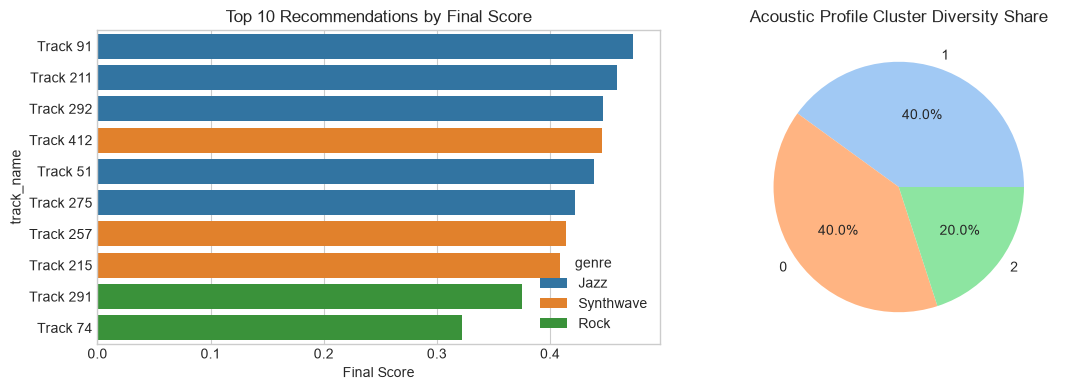

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=top10_recs, y="track_name", x="final_score", hue="genre", dodge=False, ax=ax1)
ax1.set_title("Top 10 Recommendations by Final Score")
ax1.set_xlabel("Final Score")

top10_recs["cluster_id"].value_counts().plot(kind="pie", autopct="%1.1f%%", ax=ax2, colors=sns.color_palette("pastel"))
ax2.set_title("Acoustic Profile Cluster Diversity Share")

plt.tight_layout()
plt.savefig("../docs/figures/13_recommendations_summary.png", dpi=300)
plt.show()


## Discussion: Recommendation vs Prediction, Cold Start & Evaluation

### 1. Recommendation vs. Prediction
- **Prediction**: Supervised ML models (e.g. Decision Trees) map features to a target label (e.g., predicting an anxiety severity score $Y \in [0, 10]$).
- **Recommendation**: Unsupervised/Content-based ranking orders items based on vector distance and preference compatibility.

### 2. Cold Start Problem
- **Problem**: When a user has 0 listening events, no profile vector can be computed.
- **Solution Strategies**: Default to overall popular catalog tracks, onboarding genre preference checkboxes, or demographic group averages.

### 3. Non-Causal Boundary
- **Boundary**: Recommendations match user musical preferences and acoustic context. We **NEVER** claim *"Song X cures anxiety"*. Any anxiety association remains strictly observational.

### 4. Recommendation Evaluation Metrics
- **Offline Evaluation**: Precision@K, Recall@K, NDCG@K, Diversity, Novelty.
- **Online Evaluation**: Click-Through Rate (CTR), Skip Rate, Session Completion Rate.
